In [7]:
import pandas as pd

# Load the data
df = pd.read_csv('/content/ecommerce_customer_data.csv')
df.head()


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Membership_Years,Online_Purchases,Discount_Usage,Churn
0,1,56,Male,69812,88,3.2,92,0.43,1
1,2,69,Female,70500,26,4.3,30,0.23,1
2,3,46,Female,99151,17,8.2,199,0.52,0
3,4,32,Male,78643,71,0.6,153,0.25,0
4,5,60,Female,64900,13,6.7,127,0.94,0


In [9]:
# The data types and if there are any empty (null) cells
df.info()

# Statistical summary (Mean, Max, Min) of the numbers
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       2000 non-null   int64  
 1   Age               2000 non-null   int64  
 2   Gender            2000 non-null   object 
 3   Annual_Income     2000 non-null   int64  
 4   Spending_Score    2000 non-null   int64  
 5   Membership_Years  2000 non-null   float64
 6   Online_Purchases  2000 non-null   int64  
 7   Discount_Usage    2000 non-null   float64
 8   Churn             2000 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 140.8+ KB


,Customer_ID,Age,Annual_Income,Spending_Score,Membership_Years,Online_Purchases,Discount_Usage,Churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,43.805500,84089.382500,50.448500,5.248000,97.976000,0.489155,0.310500
std,577.494589,14.929203,37446.608502,28.411793,2.759783,57.314858,0.281573,0.462814
min,1.000000,18.000000,20112.000000,1.000000,0.500000,1.000000,0.000000,0.000000
25%,500.750000,31.000000,50810.750000,25.000000,2.875000,50.000000,0.250000,0.000000
50%,1000.500000,44.000000,84476.500000,50.500000,5.200000,93.000000,0.480000,0.000000
75%,1500.250000,56.000000,115550.750000,75.250000,7.700000,147.000000,0.730000,1.000000
max,2000.000000,69.000000,149936.000000,99.000000,10.000000,199.000000,1.000000,1.000000


In [10]:
# Duplicate rows?
print(f"Number of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 0


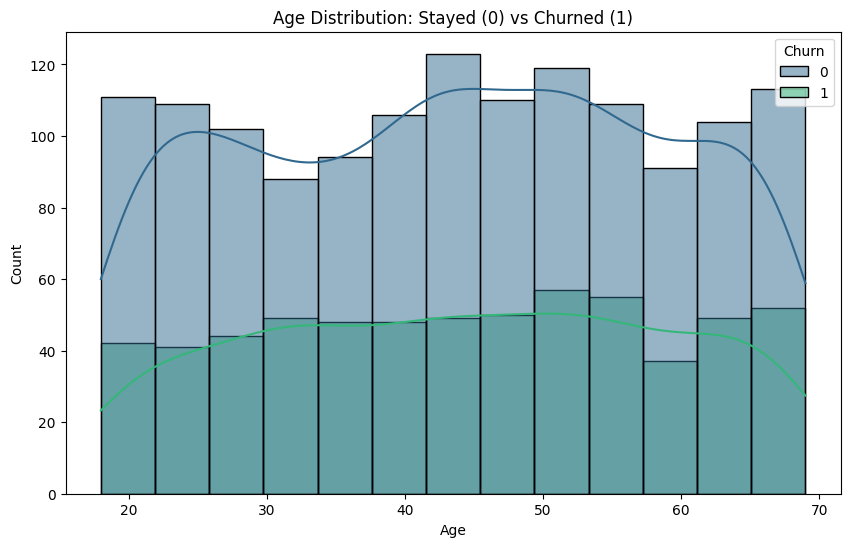

In [12]:
# Does Age play a role in people leaving
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Churn', kde=True, palette='viridis')
plt.title('Age Distribution: Stayed (0) vs Churned (1)')
plt.show()


/tmp/ipykernel_12236/2970957345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Annual_Income', palette='magma')


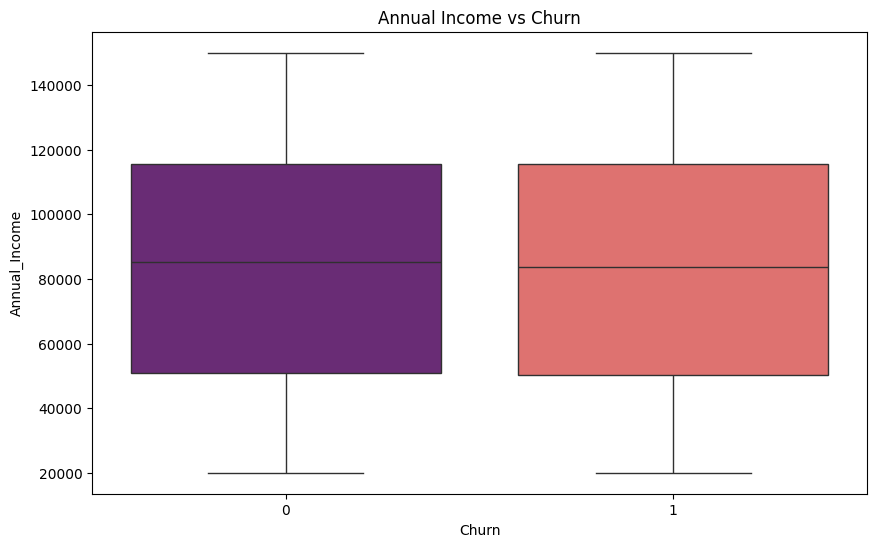

In [13]:
#  Box plot for comparing categories
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='Annual_Income', palette='magma')
plt.title('Annual Income vs Churn')
plt.show()


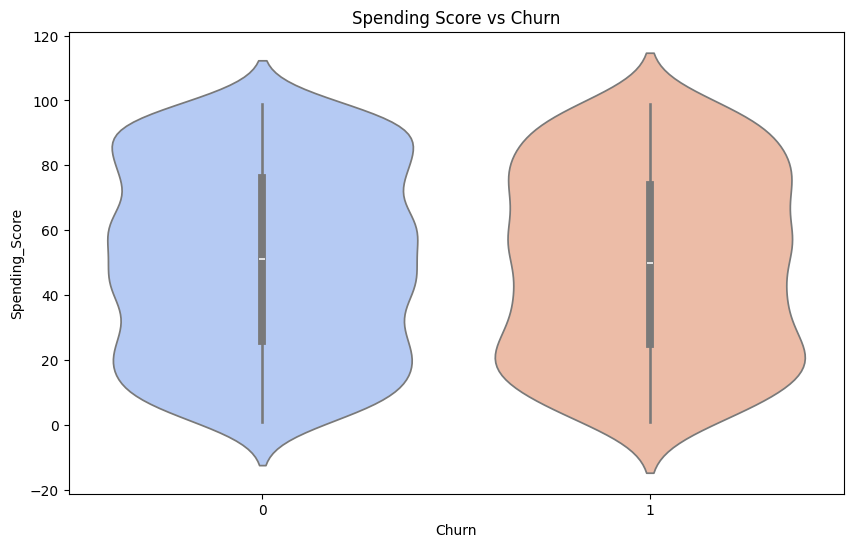

In [14]:
#  Violin plot to check the spending score
plt.figure(figsize=(10, 6))
# Using 'hue' instead of 'palette' to keep the code modern
sns.violinplot(data=df, x='Churn', y='Spending_Score', hue='Churn', palette='coolwarm', legend=False)
plt.title('Spending Score vs Churn')
plt.show()


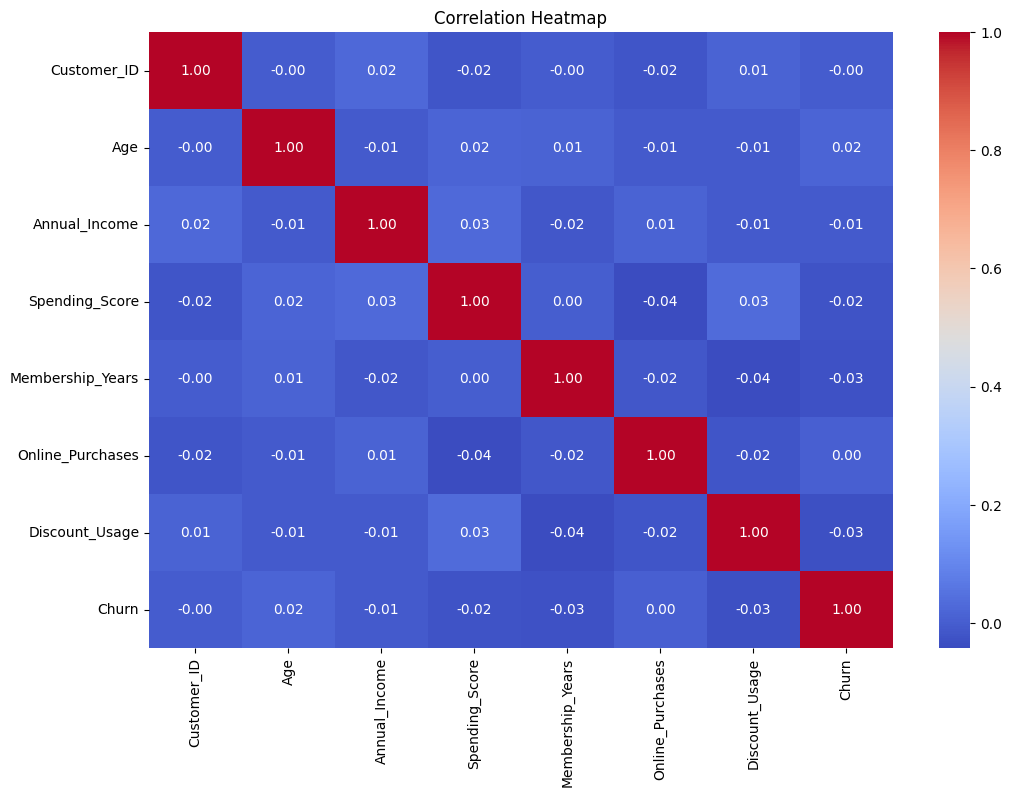

In [15]:
# Correlation Heatmap
import numpy as np

plt.figure(figsize=(12, 8))
# We only correlate numeric columns
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()



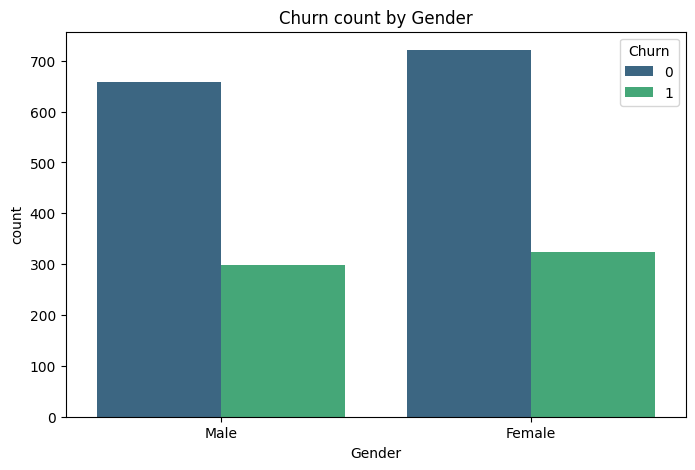

In [16]:
# non-numeric "Categorical" data
# bar chart for every "Text" column to check how they impact Churn
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'Churn count by {col}')
    plt.show()


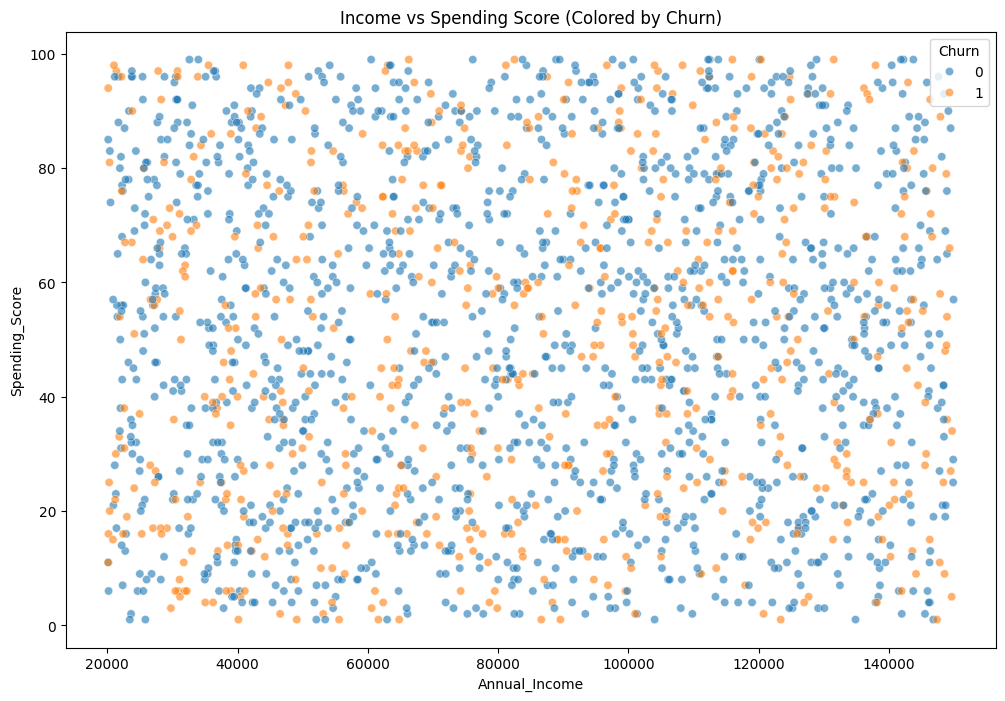

In [17]:
#  Scatter Plot to check: Annual Income (x), Spending Score (y), and Churn (color)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Churn', alpha=0.6)
plt.title('Income vs Spending Score (Colored by Churn)')
plt.show()


In [18]:
# can decision Tree solve the puzzle?

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Prepare data (convert text to numbers)
df_ml = pd.get_dummies(df, drop_first=True)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

# 4. Check Accuracy
predictions = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2%}")


Model Accuracy: 66.25%


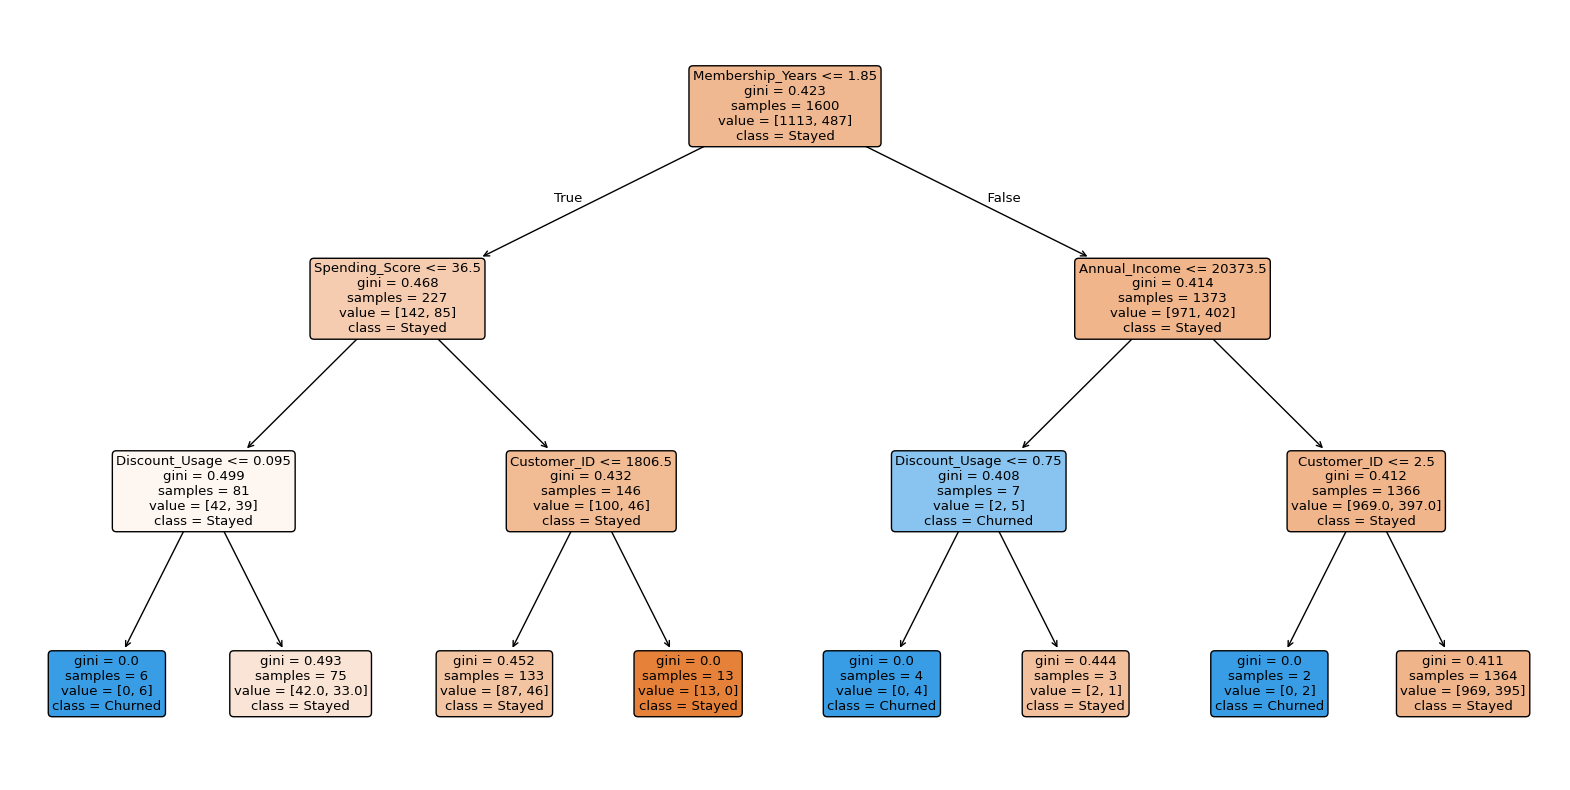

In [19]:
# the logic that computer built
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['Stayed', 'Churned'], filled=True, rounded=True)
plt.show()
